# **Federated Site Simulation and Splits**
---

Here, I partitioned the dataset into train/val/test splits (stratified, leakage-free) and then simulated 5 Nigerian teaching hospital sites using Dirichlet partitioning. I save per-site DataFrames and visualise the resulting class distribution across sites.

In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

USE_MOCK_DATA = True

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from src.config import load_config
from src.paths import get_paths
from src.data_utils import dirichlet_split, uniform_split
from src.visualization import set_publication_style, save_figure, plot_site_class_distribution

cfg   = load_config()
paths = get_paths()
set_publication_style()

SEED    = cfg["project"]["random_seed"]
N_SITES = cfg["federated"]["num_clients"]
ALPHA   = cfg["federated"]["dirichlet_alpha"]
SITE_NAMES = cfg["federated"]["site_names"]

manifest = pd.read_csv(paths["interim"] / "manifest_clean.csv")
print(f"Loaded manifest: {manifest.shape}")
print(f"Label distribution: {dict(manifest['label'].value_counts())}")

Loaded manifest: (800, 5)
Label distribution: {0: 406, 1: 394}


## Global Train / Val / Test Split

I perform the split FIRST, before any site partitioning.

**Why this order matters:**
If I split into sites first, then into train/val/test, the val and test sets could contain data from the same image-generating process as training at some sites. The global test set must be site-agnostic — it evaluates the global FL model after all rounds.

Split proportions: 70% train | 15% val | 15% test (stratified by label).

In [2]:
# Step 1a: Stratified split into train and temp (val+test)
train_df, temp_df = train_test_split(
    manifest,
    test_size=cfg["splits"]["test_size"] + cfg["splits"]["val_size"],  # 30%
    stratify=manifest["label"],
    random_state=SEED,
)

# Step 1b: Split temp into val and test (50/50 of 30% → 15% each)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,   # Half of the temp set
    stratify=temp_df["label"],
    random_state=SEED,
)

print(f"Split sizes:")
print(f"  Train : {len(train_df)} ({100*len(train_df)/len(manifest):.1f}%)")
print(f"  Val   : {len(val_df)} ({100*len(val_df)/len(manifest):.1f}%)")
print(f"  Test  : {len(test_df)} ({100*len(test_df)/len(manifest):.1f}%)")
print()
print("Label distribution in each split:")
for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    pos_rate = 100 * (df["label"] == 1).mean()
    print(f"  {name}: {pos_rate:.1f}% TB positive")

print()
print("Leakage check: are any image paths shared between splits?")
train_paths = set(train_df["image_path"])
val_paths   = set(val_df["image_path"])
test_paths  = set(test_df["image_path"])
overlap_tv = train_paths & val_paths
overlap_tt = train_paths & test_paths
overlap_vt = val_paths   & test_paths
print(f"  Train ∩ Val  : {len(overlap_tv)} (should be 0)")
print(f"  Train ∩ Test : {len(overlap_tt)} (should be 0)")
print(f"  Val   ∩ Test : {len(overlap_vt)} (should be 0)")

assert len(overlap_tv) == 0, "LEAKAGE: train and val share images!"
assert len(overlap_tt) == 0, "LEAKAGE: train and test share images!"
assert len(overlap_vt) == 0, "LEAKAGE: val and test share images!"
print("  ✓ No overlap detected — splits are clean.")

Split sizes:
  Train : 560 (70.0%)
  Val   : 120 (15.0%)
  Test  : 120 (15.0%)

Label distribution in each split:
  Train: 49.3% TB positive
  Val: 49.2% TB positive
  Test: 49.2% TB positive

Leakage check: are any image paths shared between splits?
  Train ∩ Val  : 0 (should be 0)
  Train ∩ Test : 0 (should be 0)
  Val   ∩ Test : 0 (should be 0)
  ✓ No overlap detected — splits are clean.


## Dirichlet Partition into Hospital Sites

I partition only the TRAINING set into sites. Val and test remain global (shared across sites for evaluation).

The Dirichlet distribution with parameter α produces a probability vector over N sites. Low α (e.g., 0.1) concentrates probability — one site gets most of the data. High α (e.g., 10) spreads data uniformly.

We use α=0.5 by default, which produces moderate heterogeneity, realistic for hospitals in different cities with different patient populations.

In [3]:
# Partition training set indices using Dirichlet distribution
client_indices = dirichlet_split(
    labels=train_df["label"].values,
    num_clients=N_SITES,
    alpha=ALPHA,
    min_samples=cfg["federated"]["min_samples_per_client"],
    seed=SEED,
)

print(f"Dirichlet partition (α={ALPHA}) across {N_SITES} sites:")
site_dfs = {}
site_label_dict = {}

for i, indices in enumerate(client_indices):
    site_df = train_df.iloc[indices].copy().reset_index(drop=True)
    site_df["site"] = SITE_NAMES[i]
    site_dfs[SITE_NAMES[i]] = site_df
    site_label_dict[SITE_NAMES[i]] = site_df["label"].tolist()

    n_pos = (site_df["label"] == 1).sum()
    n_neg = (site_df["label"] == 0).sum()
    pos_rate = 100 * n_pos / len(site_df) if len(site_df) > 0 else 0
    print(f"  Site {i+1} ({SITE_NAMES[i][:30]}...):")
    print(f"    n={len(site_df)}, TB+: {n_pos}, TB-: {n_neg}, TB+ rate: {pos_rate:.1f}%")

  [dirichlet_split] Attempt 1: min client size = 10, retrying with fresh Dirichlet draw...
Dirichlet partition (α=0.5) across 5 sites:
  Site 1 (Lagos_University_Teaching_Hosp...):
    n=277, TB+: 143, TB-: 134, TB+ rate: 51.6%
  Site 2 (Aminu_Kano_Teaching_Hospital...):
    n=82, TB+: 39, TB-: 43, TB+ rate: 47.6%
  Site 3 (University_of_Nigeria_Teaching...):
    n=60, TB+: 0, TB-: 60, TB+ rate: 0.0%
  Site 4 (Obafemi_Awolowo_University_Tea...):
    n=88, TB+: 68, TB-: 20, TB+ rate: 77.3%
  Site 5 (University_College_Hospital_Ib...):
    n=53, TB+: 26, TB-: 27, TB+ rate: 49.1%


Figure saved: 'site_class_distribution.png' and 'site_class_distribution.pdf'


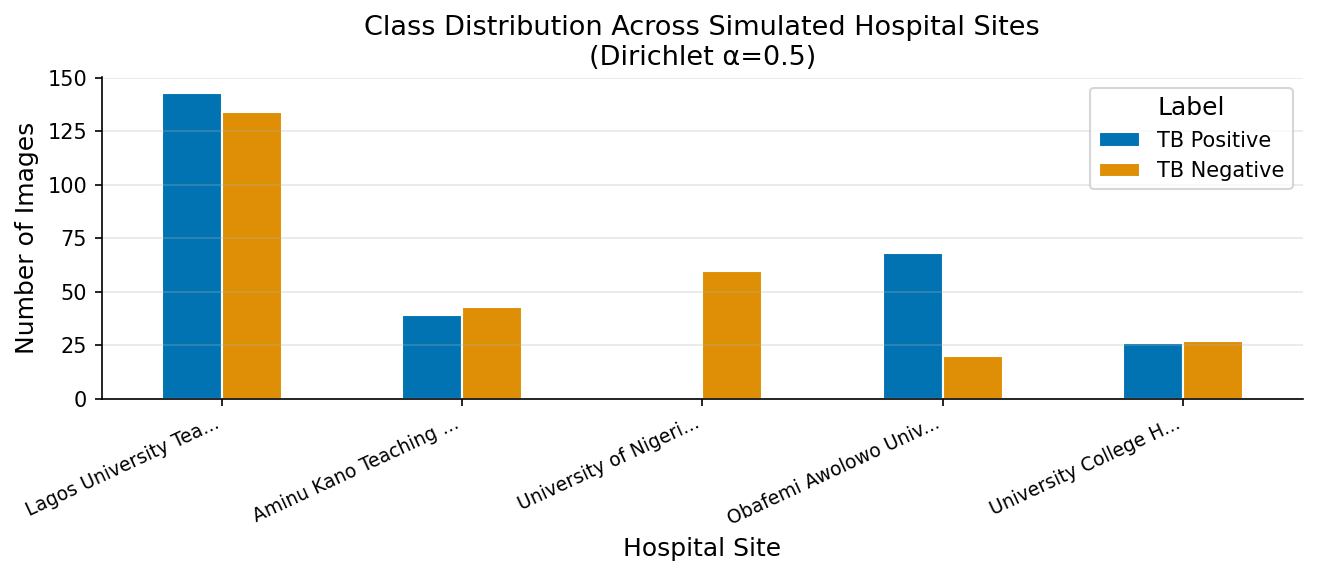

Interpretation:
  Under heterogeneous partitioning (α < 1), some sites have many more
  TB-positive cases than others. This simulates realistic differences
  between a referral hospital (high TB burden) and a general hospital
  (lower TB burden).


In [4]:
# Visualise site class distributions
fig = plot_site_class_distribution(
    site_labels=site_label_dict,
    title=f"Class Distribution Across Simulated Hospital Sites\n(Dirichlet α={ALPHA})"
)
# Truncate long site names for readability
ax = fig.axes[0]
ax.set_xticklabels(
    [name.replace("_", " ")[:20] + "..." for name in site_label_dict.keys()],
    rotation=25, ha="right", fontsize=9
)
plt.tight_layout()
save_figure(fig, "site_class_distribution", paths["figures"], paths["paper_figures"])
plt.show()

print("Interpretation:")
print("  Under heterogeneous partitioning (α < 1), some sites have many more")
print("  TB-positive cases than others. This simulates realistic differences")
print("  between a referral hospital (high TB burden) and a general hospital")
print("  (lower TB burden).")

In [5]:
# Save all splits to data/processed/
train_df.to_csv(paths["processed"] / "train.csv",  index=False)
val_df.to_csv(  paths["processed"] / "val.csv",    index=False)
test_df.to_csv( paths["processed"] / "test.csv",   index=False)

for i, (site_name, site_df) in enumerate(site_dfs.items()):
    fname = f"site_{i}_train.csv"
    site_df.to_csv(paths["processed"] / fname, index=False)

print("Saved:")
print(f"  data/processed/train.csv ({len(train_df)} rows)")
print(f"  data/processed/val.csv   ({len(val_df)} rows)")
print(f"  data/processed/test.csv  ({len(test_df)} rows)")
for i, name in enumerate(site_dfs.keys()):
    print(f"  data/processed/site_{i}_train.csv ({len(site_dfs[name])} rows)")

# Save site statistics table
site_stats = []
for i, (site_name, site_df) in enumerate(site_dfs.items()):
    site_stats.append({
        "site_id": i,
        "site_name": site_name,
        "n_total": len(site_df),
        "n_positive": int((site_df["label"]==1).sum()),
        "n_negative": int((site_df["label"]==0).sum()),
        "positive_rate": round(100*(site_df["label"]==1).mean(), 2),
    })
site_stats_df = pd.DataFrame(site_stats)
site_stats_df.to_csv(paths["tables"] / "site_statistics.csv", index=False)
print(f"\nSite statistics saved: {paths['tables']}/site_statistics.csv")

Saved:
  data/processed/train.csv (560 rows)
  data/processed/val.csv   (120 rows)
  data/processed/test.csv  (120 rows)
  data/processed/site_0_train.csv (277 rows)
  data/processed/site_1_train.csv (82 rows)
  data/processed/site_2_train.csv (60 rows)
  data/processed/site_3_train.csv (88 rows)
  data/processed/site_4_train.csv (53 rows)

Site statistics saved: C:\Users\Peter\Documents\projects\Data_science\fedtb_nigeria\reports\tables/site_statistics.csv


## Leakage Audit

Before proceeding, I explicitly confirm:
1. The test set is not used in any site partition
2. The val set is not used in any site partition
3. No site partition overlaps with any other site's training data
(Sites may overlap in the original dataset metadata but not in the train split's image paths)

In [6]:
test_paths = set(test_df["image_path"])
val_paths  = set(val_df["image_path"])

all_site_paths = set()
for site_df in site_dfs.values():
    site_paths = set(site_df["image_path"])
    overlap_with_test = site_paths & test_paths
    overlap_with_val  = site_paths & val_paths
    assert len(overlap_with_test) == 0, f"LEAKAGE: site training data overlaps with test set!"
    assert len(overlap_with_val)  == 0, f"LEAKAGE: site training data overlaps with val set!"
    all_site_paths |= site_paths

print("✓ No site training data overlaps with the test set.")
print("✓ No site training data overlaps with the val set.")
print(f"✓ Total unique training images across all sites: {len(all_site_paths)}")
print(f"  (Should match train split size: {len(train_df)})")

✓ No site training data overlaps with the test set.
✓ No site training data overlaps with the val set.
✓ Total unique training images across all sites: 560
  (Should match train split size: 560)
